# Tutorial of *Flow Matching for Applied Mathematicians* : observation of the scheduler

This notebook enables the reproduction of several figures from the paper *Flow Matching for Applied Mathematicians*. It builds on the previous notebook by illustrating the effect of changing the scheduler. It can also be easily adapted as an introductory tutorial for educational purposes. We consider now the setting of the generalized flow matching where
$$
X_t = a_t X_1 + b_tX_0
$$

### Packages and illustrations code

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
import matplotlib as mpl

In [34]:
def gaussian_contour(mean, cov, ax=None, levels=[.5,1,1.5,2], n_points=200, **kwargs):
    """
    Plots contour lines of a two-dimensional Gaussian distribution defined by 
    the given mean and covariance matrix.
    """
    if ax is None:
        fig, ax = plt.subplots()
    
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    stds = np.sqrt(np.diag(cov))
    x = np.linspace(mean[0]-4*stds[0], mean[0]+4*stds[0], n_points)
    y = np.linspace(mean[1]-4*stds[1], mean[1]+4*stds[1], n_points)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    
    inv_cov = np.linalg.inv(cov)
    diff = pos - mean
    mahal = np.einsum('...i,ij,...j->...', diff, inv_cov, diff)

    cs = ax.contour(X, Y, mahal, levels=[l**2 for l in levels], **kwargs)

    # Centre
    ax.plot(mean[0], mean[1], 'o', color=kwargs.get('colors'))

    return cs, ax




def euler_solver(x0,v,n_steps=100,T=1) :
    """
    Solves an ordinary differential equation using the explicit Euler method.
    Starting from an initial state `x0`, the solver advances the solution over
    the time interval [0, T] using `n_steps` uniformly spaced steps. The vector
    field is provided as a Python function `v(t, x)`. The function returns an
    array containing the complete trajectory, including the initial state.
    """
    times = np.linspace(0,T,n_steps+1)
    t = times[0]
    xts = np.zeros((n_steps+1, *x0.shape))
    xt = x0
    xts[0] = xt.copy()
    for i in range(n_steps) :
        dt = times[i+1]-times[i]
        xt = xt+dt*v(t,xt)
        xts[i+1] = xt.copy()
        t += dt
    return xts

In [35]:
#We use a consistent color palette throughout the notebook, defined below.
color_source = '#648FFF'
color_target = '#DC267F'
color_trajectories = '#323232'

cmap_path = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_path",
    [color_source, color_target]
)

## Schedule

You can specify a scheduler below (or create your own).

In [57]:
schedule = "sqrt"


if schedule =='linear' :
    def a(t) :
        return t
    def a_dot(t) :
        return 1
    def b(t) :
        return 1-t
    def b_dot(t) :
        return -1
if schedule =='cosine' :
    def a(t):
        return np.sin(np.pi/2 * t)
    def a_dot(t):
        return (np.pi/2) * np.cos(np.pi/2 * t)
    def b(t):
        return np.cos(np.pi/2 * t)
    def b_dot(t):
        return - (np.pi/2) * np.sin(np.pi/2 * t)
if schedule =='sqrt' :
    def a(t):
        return t
    def a_dot(t):
        return 1
    def b(t):
        return np.sqrt(1 - t**2)
    def b_dot(t):
        return - t / np.sqrt(1 - t**2)

if schedule =='square' :
    def a(t):
        return t**2
    def a_dot(t):
        return 2*t
    def b(t):
        return (1-t)**2
    def b_dot(t):
        return -2*(1-t)




# Gaussian setting

### Reminder and code of the velocity field formula

As a reminder, if we consider the coupling $(X_0,X_1)\sim\mathcal N(m,\Sigma)$ with
$m=\begin{pmatrix}m_0 \\ m_1 \end{pmatrix}$
and
$
\Sigma=\begin{pmatrix}\Sigma_{0}&\Sigma_{10}\\\Sigma_{01}&\Sigma_{1}\end{pmatrix},
$ the velocity field can be written as
$$
    v_t(x)= (\dot{a}_t m_1 +\dot{b}_t m_0)
+\left[\left(\dot a_t - \frac{\dot b_t}{b_t}\,a_t\right)(b_t\Sigma_{10} + a_t \Sigma_1) \Sigma_t^{-1}
      + \frac{\dot b_t}{b_t}\right] 
(x - m_t),
$$
with $m_t = b_tm_0+a_tm_1$ and $\Sigma_t=b_t^2\Sigma_0+a_tb_t(\Sigma_{01}+\Sigma_{01})+a^2_t\Sigma_1$.
We provide the code below.

In [58]:
def m_t(t,m0,m1):
    return a(t)* m1 +b(t)* m0

def Sigma_t(t,Sigma0,Sigma1,Sigma01):
    return a(t)**2 * Sigma1 + (b(t) ** 2) *Sigma0+a(t)*b(t)*(Sigma01+Sigma01.T)


def v_Gaussian(t, x, m0, m1, Sigma0, Sigma1, Sigma01):
    at = a(t)
    bt = b(t)
    at_dot = a_dot(t)
    bt_dot = b_dot(t)

    mt = m_t(t, m0, m1)                   
    St = Sigma_t(t, Sigma0, Sigma1, Sigma01)

    const = at_dot * m1 + bt_dot * m0      

    linear_mat = (at_dot - (bt_dot / bt) * at)* (bt * Sigma01 + at * Sigma1) @ np.linalg.inv(St)  

    dx = (x - mt)                        
    linear_term = dx @ linear_mat.T       

    drift_term = (bt_dot / bt) * dx       

    v = const + linear_term + drift_term  
    return v


### Illustrative examples

We reproduce the experiments from the paper by simulating Flow Matching between pairs of Gaussian distributions, considering both independent and dependent cases.

(-21.908902300206645,
 224.87094820479328,
 -21.908902300206645,
 21.908902300206645)

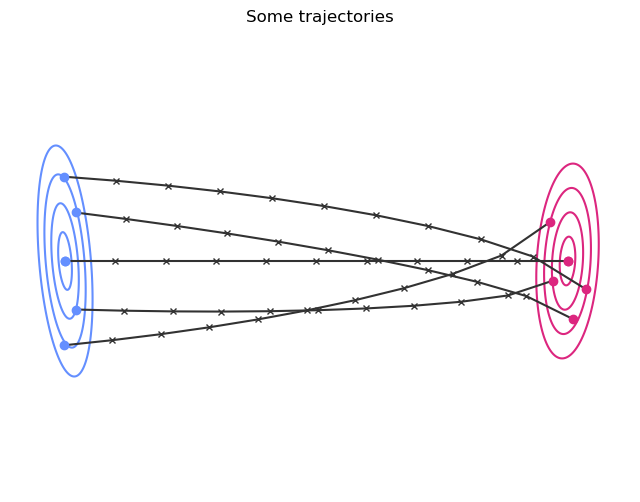

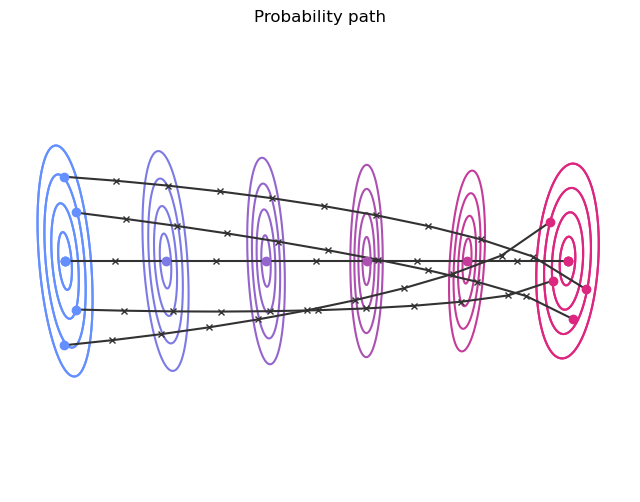

In [59]:
####################################################################
# Dependent case
####################################################################
m0 = np.array([0.0, 0.0])

Sigma0 = np.array(([[ 30., -10.],
                     [-10.,  30.]]))
sqrt_Sigma0 = sqrtm(Sigma0)

b1 = 200*np.array([1.,0.])
theta=10*np.pi/3
A =np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])
Sigma1 = A.dot(Sigma0).dot(A.T)
m1 = m0+b1

Sigma01 = (A.dot(Sigma0))#Dependence is provided here

v = lambda t,x : v_Gaussian(t,x,m0,m1,Sigma0,Sigma1,Sigma01)

## Initialization and simulation of the trajectories
nb_traj = 5
n_steps = 100

# For reproduction of the paper figure:
#x0s = m0+sqrt_Sigma0.dot(np.random.randn(2,nb_traj)).T
x0s =np.array([[-.6, -8],[-.6, 8],[ 4.2, -4.6],[ 4.2, 4.6],[0.,0.]])
xts = euler_solver(x0s,v,n_steps=n_steps)


## Visualization of the trajectories
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
plt.title('Some trajectories')
plt.axis('off')

fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
selected_times = np.linspace(0,1,n_steps+1)[::20]
for t in selected_times :
    gaussian_contour( m_t(t,m0,m1), Sigma_t(t,Sigma0,Sigma1,Sigma01), ax=ax, colors=cmap_path(t),zorder=1)
plt.title('Probability path')
plt.axis('off')

(-21.908902300206645,
 224.87094820479328,
 -21.908902300206645,
 21.908902300206645)

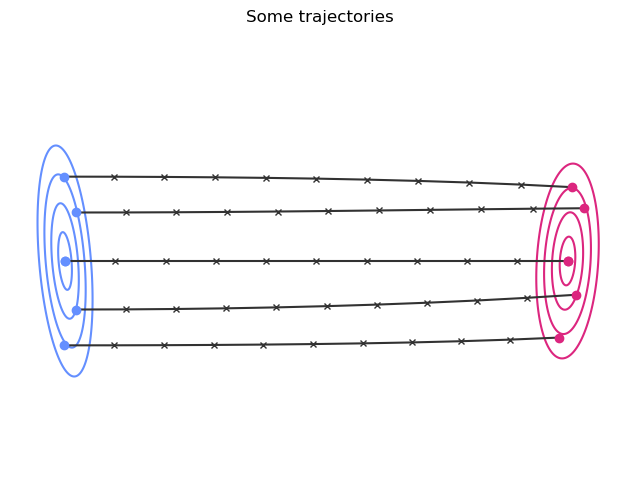

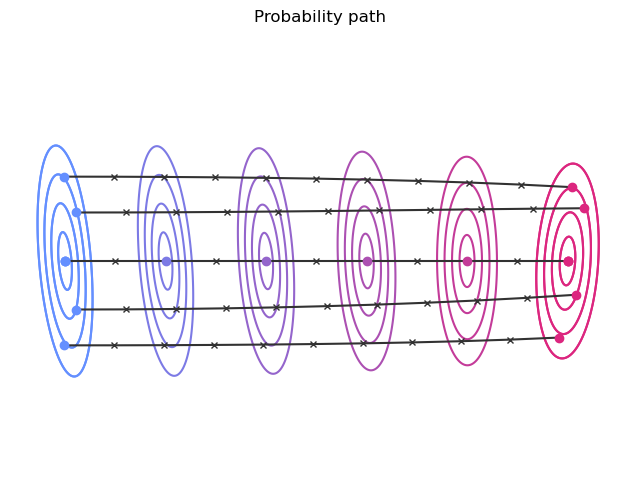

In [60]:
####################################################################
# Independent case
####################################################################
m0 = np.array([0.0, 0.0])

Sigma0 = np.array(([[ 30., -10.],
                     [-10.,  30.]]))
sqrt_Sigma0 = sqrtm(Sigma0)

b1 = 200*np.array([1.,0.])
theta=10*np.pi/3
A =np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

Sigma1 = A.dot(Sigma0).dot(A.T)
m1 = m0+b1

Sigma01 = np.zeros((2,2)) #Independence is provided here

v = lambda t,x : v_Gaussian(t,x,m0,m1,Sigma0,Sigma1,Sigma01)

## Initialization and simulation of the trajectories
nb_traj = 5
n_steps = 100

# For reproduction of the paper figure:
#x0s = m0+sqrt_Sigma0.dot(np.random.randn(2,nb_traj)).T
x0s =np.array([[-.6, -8],[-.6, 8],[ 4.2, -4.6],[ 4.2, 4.6],[0.,0.]])
xts = euler_solver(x0s,v,n_steps=n_steps)


## Visualization of the trajectories
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
plt.title('Some trajectories')
plt.axis('off')

## Visualization of the probability path
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
selected_times = np.linspace(0,1,n_steps+1)[::20]
for t in selected_times :
    gaussian_contour( m_t(t,m0,m1), Sigma_t(t,Sigma0,Sigma1,Sigma01), ax=ax, colors=cmap_path(t),zorder=1)
plt.title('Probability path')
plt.axis('off')

# Gaussian to a sum of Dirac setting

### Reminder and code of the velocity field formula

As a reminder, if $X_0 \sim \mathcal{N}(0,I)$ and $X_1 = \sum_{k = 0}^n \frac{1}{n} \delta_{x^{(k)}}$,
the velocity field is given by
$$
v_t(x)
=
\frac{\dot b_t}{b_t}\, x
+
\left(\dot a_t - a_t \frac{\dot b_t}{b_t}\right)
\sum_{k=1}^n \alpha_k(t,x)\, x^{(k)}.
$$
where $\alpha(t,x) = \mathrm{softmax}\left(-\frac{1}{2b_t^2}\|x-a_tx^{(i)}\|^2\right)_{1 \leq i \leq n}$ ie $\alpha_k(t,x) = \displaystyle\frac{
\exp\!\left( -\frac{\|x - a_t x^{(k)}\|^2}{2 b_t^2}\right)
}{
\sum_{j=1}^n 
\exp\!\left( -\frac{\|x - a_t x^{(j)}\|^2}{2 b_t^2}\right)
}.$.

The corresponding code is below.

In [52]:
def softmax(z):
    z = np.asarray(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)



def alpha(t, x, X):
    x = np.asarray(x)
    X = np.asarray(X)
    diff = x[:, None, :] - a(t) * X[None, :, :]  
    exponent_terms = -0.5 * np.sum(diff**2, axis=2) / (b(t)**2)
    alpha_vals = softmax(exponent_terms)  

    return alpha_vals


def v_Gaussian_to_Dirac(t, x, X):
    x = np.asarray(x)
    X = np.asarray(X)

    alpha_vals = alpha(t, x, X)

    EX1 = np.sum(alpha_vals[:, :, None] * X[None, :, :], axis=1)

    vt = (b_dot(t)/b(t)) * x + (a_dot(t) - a(t)*b_dot(t)/b(t)) * EX1

    return vt


### Illustrative example

(-4.0, 4.0, -4.0, 4.0)

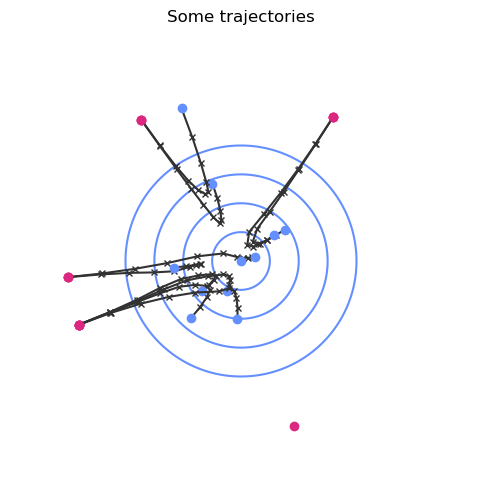

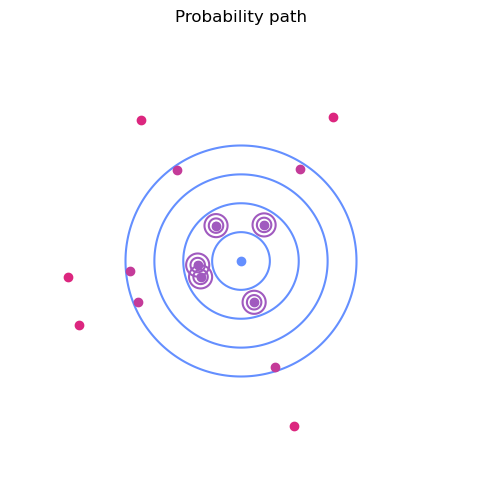

In [53]:
#Source
m0 = np.array([0.0, 0.0])
Sigma0 = np.eye(2)
sqrt_Sigma0 = sqrtm(Sigma0)

#Target
X = np.array([[-3., -0.28],
       [-1.73,  2.45],
       [ 1.6,  2.5],
       [-2.8, -1.1 ],
       [ 0.91, -2.86]])

v = lambda t,x : v_Gaussian_to_Dirac(t,x,X)

#Simulation of trajectories
nb_traj = 10
x0s = m0+sqrt_Sigma0.dot(np.random.randn(2,nb_traj)).T
n_steps = 100
xts = euler_solver(x0s,v,n_steps=n_steps)


## Visualization of the trajectories
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
plt.scatter(X[:,0],X[:,1] ,marker='o',color=color_target)
plt.title('Some trajectories')
plt.axis('off')
plt.axis('scaled')

## Visualization of the probability path
fig, ax = plt.subplots(figsize=(8,6))
# Ellipses
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source)
plt.scatter(X[:,0],X[:,1] ,marker='o',color=color_target)
t = .5
lvls = [.2,.5,.8]
for k in range(len(X)) :
    gaussian_contour( m_t(t,m0,X[k]), Sigma_t(t,Sigma0,0*np.eye(2),0*Sigma0), ax=ax, levels=lvls, colors=cmap_path(t))
t=.8
lvls = [.2,.6,.9]
for k in range(len(X)) :
    gaussian_contour( m_t(t,m0,X[k]), Sigma_t(t,Sigma0,0*np.eye(2),0*Sigma0), ax=ax, levels=lvls, colors=cmap_path(t))

ax.set_aspect('equal')
plt.title('Probability path')
plt.axis('off')

# Gaussian mixtures setting

## Independent case

### Reminder and code of the velocity field formula in the independent case

Let
$$
X_0 \sim \sum_{i=1}^{K_0}\pi_i^{(0)}\,\mathcal N\!\big(m_0^{\,i},\Sigma_0^{\,i}\big),
\qquad
X_1 \sim \sum_{j=1}^{K_1}\pi_j^{(1)}\,\mathcal N\!\big(m_1^{\,j},\Sigma_1^{\,j}\big),
$$
be independent Gaussian mixture models with $\pi_i^{(0)}, \pi_j^{(1)} > 0$ and
$\sum_i \pi_i^{(0)} = \sum_j \pi_j^{(1)} = 1$.
Then the conditional mean velocity field $v_t$
can be expressed as
$$
v_t(x) = \sum_{i=1}^{K_0}\sum_{j=1}^{K_1} \alpha_{ij}(x)\, w_t^{ij}(x),
$$
where the posterior weights are given by
$
\alpha_{ij}(x)
= \frac{\pi_i^{(0)}\pi_j^{(1)}\,p_t^{ij}(x)}
{\displaystyle \sum_{m=1}^{K_0}\sum_{n=1}^{K_1}\pi_m^{(0)}\pi_n^{(1)}\,p_t^{mn}(x)},
$
and $p_t^{ij}(x)$ is the density of the Gaussian distribution
$\mathcal N(m_t^{ij}, \Sigma_t^{ij})$ with
$
m_t^{ij} = (1-t)m_0^{\,i} + t\,m_1^{\,j},
$ and $
\Sigma_t^{ij} = (1-t)^2\Sigma_0^{\,i} + t^2\Sigma_1^{\,j}
$.
For each component pair $(i,j)$, the conditional velocity field is the velocity field between the two Gaussian $\mathcal{N}(\mu_i,\Sigma_i)$ and $\mathcal{N}(\mu_j,\Sigma_j)$ given above.

In [54]:
def gaussian_pdf(x, mean, cov):
    d = len(x)
    xc = x - mean
    norm = np.sqrt((2*np.pi)**d * np.linalg.det(cov))
    return np.exp(-0.5 * np.sum(xc*np.linalg.solve(cov, xc.T).T,axis=1)) / norm


def w_t_ij(x, i, j, t, m0s, m1s, Sigma0s, Sigma1s):

    at = a(t); bt = b(t)
    at_dot = a_dot(t); bt_dot = b_dot(t)

    m0 = m0s[i]; m1 = m1s[j]
    S0 = Sigma0s[i]; S1 = Sigma1s[j]

    mt = a(t)*m1 + b(t)*m0
    St = a(t)**2 * S1 + b(t)**2 * S0
    St_inv = np.linalg.inv(St)

    dx = x - mt

    const = at_dot*m1 + bt_dot*m0
    lin   = (at_dot*at*S1 + bt_dot*bt*S0) @ St_inv @ dx.T

    return const + lin.T



def alpha_ij(x, t,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1):
    K0 =len(pi0)
    K1 =len(pi1)
    num = np.zeros((x.shape[0],K0, K1))
    for i in range(K0):
        for j in range(K1):
            mt, St = m_t(t,m0s[i],m1s[j]),Sigma_t(t, Sigma0s[i], Sigma1s[j],0*Sigma0s[i])
            num[:,i, j] = pi0[i] * pi1[j] * gaussian_pdf(x, mt, St)
    return num / np.sum(num, axis=(1,2), keepdims=True)




def v_GMM_independents(t,x,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1):
    A = alpha_ij(x, t,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1)
    K0 =len(pi0)
    K1 =len(pi1)
    v = np.zeros((x.shape[0],len(m0s[0])))
    for i in range(K0):
        for j in range(K1):
            v += A[:, i, j][:, None] * w_t_ij(x, i, j, t, m0s, m1s, Sigma0s, Sigma1s)
    return v

### Illustrative examples

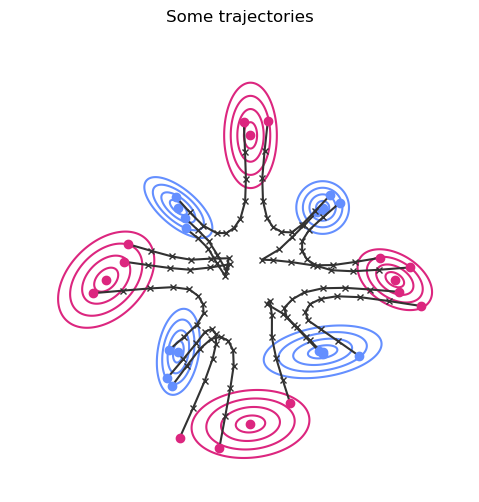

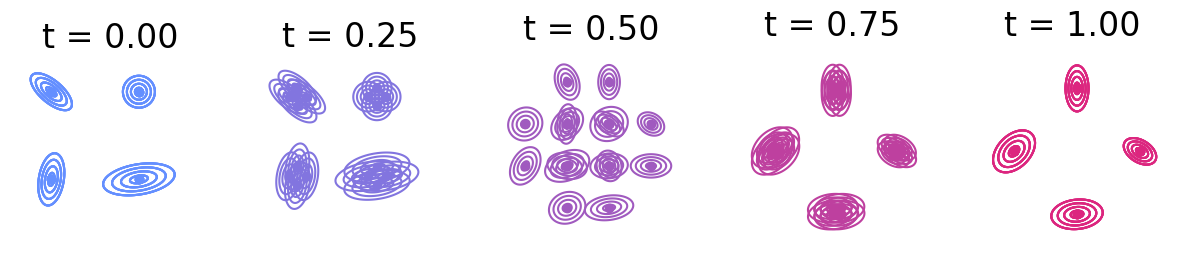

In [55]:
#Source
pi0 = np.array([0.25, 0.25, 0.25, 0.25])
m0s = np.array([
    [-3., -3.],
    [-3.,  3.],
    [ 3., -3.],
    [ 3.,  3.]
])
Sigma0s = np.array([
    [[0.2, 0.1], [0.1, 0.8]],   
    [[0.5, -0.3], [-0.3, 0.4]], 
    [[1.5, 0.2], [0.2, 0.3]],   
    [[0.3, 0.0], [0.0, 0.3]]  
])

# Target
pi1 = np.array([0.25, 0.25, 0.25, 0.25])
m1s = np.array([
    [-6.,  0.],
    [ 0.,  6.],
    [ 6.,  0.],
    [ 0., -6.]
])
Sigma1s = np.array([
    [[1.0, 0.4], [0.4, 1.0]],  
    [[0.3, 0.0], [0.0, 1.2]], 
    [[0.6, -0.2], [-0.2, 0.4]], 
    [[1.5, 0.1], [0.1, 0.5]]   
])

K0 = len(pi0)
K1 = len(pi1)



v = lambda t,x : v_GMM_independents(t,x,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1)


x0s = []
for k in range(K0):
    for _ in range(3):
        x0s.append(np.random.multivariate_normal(m0s[k], Sigma0s[k]))
x0s = np.array(x0s)
n_steps=1000
xts = euler_solver(x0s,v,n_steps=n_steps)

fig, ax = plt.subplots(figsize=(8,6))
for i in range(len(pi0)):
    gaussian_contour(m0s[i], Sigma0s[i], ax=ax, colors=color_source)
    
for i in range(len(pi1)):
    gaussian_contour(m1s[i], Sigma1s[i], ax=ax, colors=color_target)

for k in range(len(x0s)) :
    plt.plot(xts[::100,k,0],xts[::100,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)

plt.axis('scaled')
plt.axis('off')
plt.title('Some trajectories')

## Probability path

ts = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(ts), figsize=(15, 4))

for ax, t in zip(axes, ts):

    ax.set_title(f"t = {t:.2f}", fontsize=24, pad=0)

    # mixture intermédiaire : K0*K1 composantes
    for i in range(K0):
        for j in range(K1):
            mt, St = m_t(t,m0s[i],m1s[j]),Sigma_t(t, Sigma0s[i], Sigma1s[j],0*Sigma0s[i])
            gaussian_contour( mt, St,ax, colors=cmap_path(t))

    ax.axis('scaled')
    ax.axis('off')


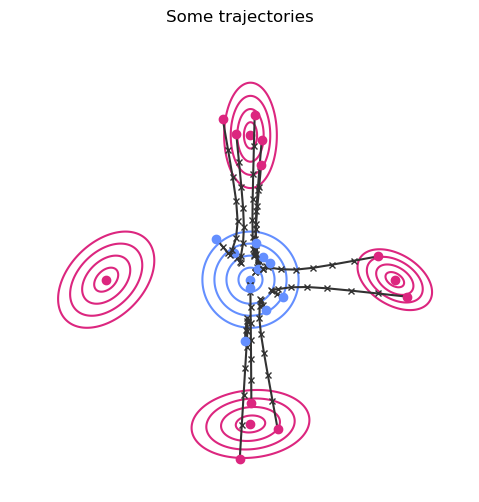

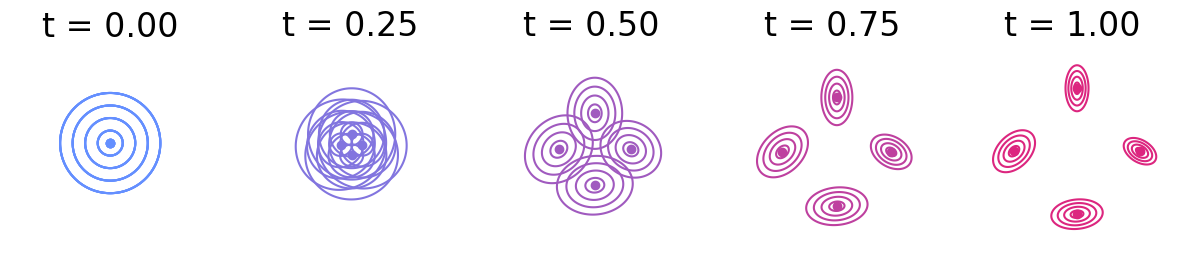

In [56]:

pi0 = np.array([1])
m0s = np.zeros((1,2))
Sigma0s = np.array([np.eye(2)])

# Target
pi1 = np.array([0.25, 0.25, 0.25, 0.25])
m1s = np.array([
    [-6.,  0.],
    [ 0.,  6.],
    [ 6.,  0.],
    [ 0., -6.]
])
Sigma1s = np.array([
    [[1.0, 0.4], [0.4, 1.0]],  
    [[0.3, 0.0], [0.0, 1.2]], 
    [[0.6, -0.2], [-0.2, 0.4]], 
    [[1.5, 0.1], [0.1, 0.5]]   
])

K0 = len(pi0)
K1 = len(pi1)



v = lambda t,x : v_GMM_independents(t,x,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1)


x0s = []
for k in range(K0):
    for _ in range(10):
        x0s.append(np.random.multivariate_normal(m0s[k], Sigma0s[k]))
x0s = np.array(x0s)
n_steps=1000
xts = euler_solver(x0s,v,n_steps=n_steps)

fig, ax = plt.subplots(figsize=(8,6))
for i in range(len(pi0)):
    gaussian_contour(m0s[i], Sigma0s[i], ax=ax, colors=color_source)
    
for i in range(len(pi1)):
    gaussian_contour(m1s[i], Sigma1s[i], ax=ax, colors=color_target)

for k in range(len(x0s)) :
    plt.plot(xts[::100,k,0],xts[::100,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)

plt.axis('scaled')
plt.axis('off')
plt.title('Some trajectories')

## Probability path

ts = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(ts), figsize=(15, 4))

for ax, t in zip(axes, ts):

    ax.set_title(f"t = {t:.2f}", fontsize=24, pad=0)

    # mixture intermédiaire : K0*K1 composantes
    for i in range(K0):
        for j in range(K1):
            mt, St = m_t(t,m0s[i],m1s[j]),m_t(t,Sigma0s[i],Sigma1s[j])
            gaussian_contour( mt, St,ax, colors=cmap_path(t))

    ax.axis('scaled')
    ax.axis('off')
